# Lab - 52087 Neural Fields

This lab explores **neural fields** (implicit neural representations) for 2D image reconstruction. We treat an image as a continuous function:
- input: pixel coordinates (x,y) (normalized to [-1,1])
- output: RGB color in [0,1]

The lab is organized into three stages.

1) Baseline MLP  
Train a standard MLP that maps 2D coordinates to RGB. You should observe the classic *low-frequency bias* (blurry reconstructions).

2) Positional Encoding (PE)  
Encode coordinates with higher-frequency features before feeding them to an MLP. We include two options commonly used in neural fields see 6.1 in [paper](https://arxiv.org/pdf/2006.10739):
- sinusoidal Fourier features (deterministic frequency bands) 
- Gaussian random Fourier features (random frequencies sampled from a Gaussian)

3) SIREN  
Replace ReLU with sine activations and use SIREN-style initialization (periodic activation as an inductive bias) to represent higher frequencies without explicit input encoding.

During training we track basic metrics (loss, PSNR; optional SSIM) and plot training dynamics. In the student version, you can remove the plotting/metrics blocks and ask students to implement them.


In [1]:

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from PIL import Image
import matplotlib.pyplot as plt

# Use GPU if available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')


Using device: cuda



## Data Preparation

To train a neural field on an image, we need a dataset of coordinate–color pairs. Each pixel location is treated as a coordinate \((x,y)\) in a continuous domain (normalized to \([-1,1]\)), and the corresponding RGB value is the target. We provide utility functions to load an image from disk or generate a synthetic pattern and then sample a dense grid of coordinates and colors.

If you want to train on your own image, place the image file in the same directory as this notebook and set `image_path` accordingly. The default synthetic pattern demonstrates the method without requiring external files.


In [2]:

from typing import Tuple

def load_image(path: str, resize: Tuple[int, int]=(128, 128)) -> np.ndarray:
    # Load an image from path, resize to the desired resolution and return a normalized
    # numpy array of shape (H, W, 3) with values in [0,1].
    img = Image.open(path).convert('RGB')
    img = img.resize(resize)
    img_np = np.asarray(img, dtype=np.float32) / 255.0
    return img_np


def generate_synthetic_image(resolution: int = 128) -> np.ndarray:
    # Generate a synthetic RGB image using sinusoidal patterns.  This avoids external
    # dependencies and provides a known ground truth with high‑frequency content.
    x = np.linspace(0, 1, resolution)
    y = np.linspace(0, 1, resolution)
    xv, yv = np.meshgrid(x, y)
    img = np.zeros((resolution, resolution, 3), dtype=np.float32)
    # Red channel: high‑frequency checkerboard pattern
    img[..., 0] = (np.sin(2 * np.pi * 6 * xv) * np.sin(2 * np.pi * 6 * yv) + 1) / 2
    # Green channel: low‑frequency radial gradient
    r = np.sqrt((xv - 0.5) ** 2 + (yv - 0.5) ** 2)
    img[..., 1] = 1 - r / np.max(r)
    # Blue channel: diagonal stripes
    img[..., 2] = (np.sin(2 * np.pi * 4 * (xv + yv)) + 1) / 2
    return img


def prepare_dataset(img: np.ndarray) -> Tuple[torch.Tensor, torch.Tensor]:
    # Given an image array of shape (H, W, 3), return tensors:
    #  coords: (N, 2) containing (x,y) in [-1,1]
    #  colors: (N, 3) containing RGB in [0,1]
    h, w, c = img.shape
    ys = np.linspace(-1.0, 1.0, h)
    xs = np.linspace(-1.0, 1.0, w)
    xv, yv = np.meshgrid(xs, ys)
    coords = np.stack([xv, yv], axis=-1).reshape(-1, 2).astype(np.float32)
    colors = img.reshape(-1, c).astype(np.float32)
    coords = torch.from_numpy(coords).to(device)
    colors = torch.from_numpy(colors).to(device)
    return coords, colors

###########################################################
### TODO: choose your own image or generate synthetic image
###########################################################

image_path = None #"image.jpg"  # e.g., 'your_image.png' or None for synthetic
resolution = 128 

if image_path is not None:
    img_np = load_image(image_path, resize=(resolution, resolution))
else:
    img_np = generate_synthetic_image(resolution)

coords, colors = prepare_dataset(img_np)
print(f"Dataset: {coords.shape[0]} samples, coordinate tensor shape {coords.shape}, color tensor shape {colors.shape}")


Dataset: 16384 samples, coordinate tensor shape torch.Size([16384, 2]), color tensor shape torch.Size([16384, 3])


## Metrics and training dynamics

We report:
- Loss (MSE / L1 / Huber)
- PSNR (higher is better)
- Optional SSIM (if `scikit-image` is installed)

We also plot training curves (loss and PSNR vs. iteration). In the student version, you can remove the plotting functions and ask students to implement them.


In [3]:
import numpy as np
import matplotlib.pyplot as plt

def mse(pred: torch.Tensor, target: torch.Tensor) -> float:
    ###########################################################
    ### TODO: Complete mse metric
    ###########################################################
    return F.mse_loss(pred, target).item()

def psnr(pred: torch.Tensor, target: torch.Tensor, data_range: float = 1.0) -> float:
    ###########################################################
    ### TODO: Complete psnr metric
    ###########################################################
    mse_value = F.mse_loss(pred, target).item()
    if mse_value == 0:
        return float('inf')
    return 20 * np.log10(data_range) - 10 * np.log10(mse_value)


def try_ssim(pred_img: np.ndarray, gt_img: np.ndarray) -> float | None:
    # Optional: requires scikit-image. Returns None if unavailable.
    ###########################################################
    ### Optional TODO: Complete ssim metric
    ###########################################################
    return None


###########################################################
# start remove
# write necessary helper functions here
# e.g.: plot training curves, show reconstructions, etc.
# end remove
###########################################################


## Stage 1 – Baseline MLP

A simple multilayer perceptron can approximate the mapping \(f_	heta : \mathbb{R}^2 	o \mathbb{R}^3\) from normalized pixel coordinates to RGB values. However, standard activations like ReLU or tanh exhibit a **low‑frequency inductive bias**—they learn smooth, low‑frequency components of the target signal first, causing reconstructions to be blurry and missing fine detail. We build a configurable MLP and a training loop that supports multiple loss functions so you can experiment with different objectives.


In [6]:

class MLP(nn.Module):
    def __init__(self, in_dim: int, hidden_dim: int, out_dim: int, num_layers: int = 4, activation=F.relu):
        super().__init__()
        self.activation = activation
        layers = []
        dim = in_dim
        for _ in range(num_layers - 1):
            layers.append(nn.Linear(dim, hidden_dim))
            dim = hidden_dim
        layers.append(nn.Linear(dim, out_dim))
        self.layers = nn.ModuleList(layers)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        for layer in self.layers[:-1]:
            x = self.activation(layer(x))
        return torch.sigmoid(self.layers[-1](x))  # sigmoid bounds outputs in [0,1]

# train_model helper function
def train_model(model: nn.Module,
                coords: torch.Tensor,
                colors: torch.Tensor,
                num_iters: int = 500,
                lr: float = 1e-3,
                loss_type: str = "mse",
                log_every: int = 200) -> tuple[nn.Module, dict]:

    if loss_type == "mse":
        criterion = nn.MSELoss()
    elif loss_type == "l1":
        criterion = nn.L1Loss()
    elif loss_type == "huber":
        criterion = nn.SmoothL1Loss()
    else:
        raise ValueError(f"Unknown loss type: {loss_type}")

    optimizer = optim.Adam(model.parameters(), lr=lr)
    model.train()

    history = {"step": [], "loss": [], "psnr": []}

    for it in range(1, num_iters + 1):
        ###########################################################
        ### TODO: complete the training code of Neural Field on MLP
        ###########################################################
        optimizer.zero_grad()
        outputs = model(coords)
        loss = criterion(outputs, colors)
        loss.backward()
        optimizer.step()
        if it % log_every == 0 or it == 1:
            with torch.no_grad():
                pred_colors = model(coords)
                current_loss = criterion(pred_colors, colors).item()
                current_psnr = psnr(pred_colors, colors)
                history["step"].append(it)
                history["loss"].append(current_loss)
                history["psnr"].append(current_psnr)
                print(f"Iter {it}/{num_iters}, Loss: {current_loss:.6f}, PSNR: {current_psnr:.2f} dB")


    return model, history


Iter 1/2000, Loss: 0.075314, PSNR: 11.23 dB
Iter 200/2000, Loss: 0.048033, PSNR: 13.18 dB
Iter 400/2000, Loss: 0.027123, PSNR: 15.67 dB
Iter 600/2000, Loss: 0.018589, PSNR: 17.31 dB
Iter 800/2000, Loss: 0.014004, PSNR: 18.54 dB
Iter 1000/2000, Loss: 0.011270, PSNR: 19.48 dB
Iter 1200/2000, Loss: 0.009451, PSNR: 20.25 dB
Iter 1400/2000, Loss: 0.008245, PSNR: 20.84 dB
Iter 1600/2000, Loss: 0.007258, PSNR: 21.39 dB
Iter 1800/2000, Loss: 0.007938, PSNR: 21.00 dB
Iter 2000/2000, Loss: 0.006462, PSNR: 21.90 dB


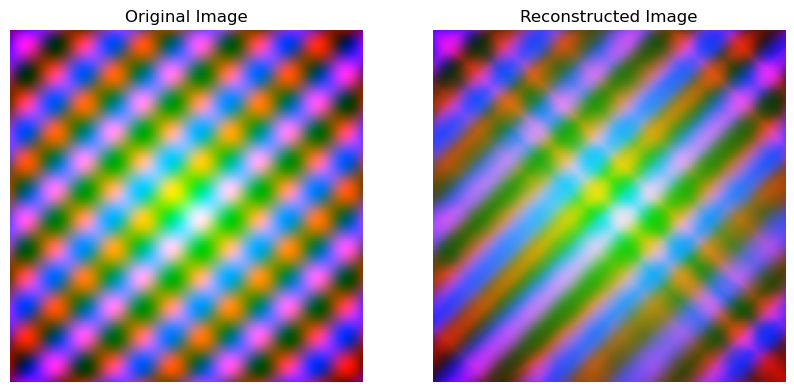

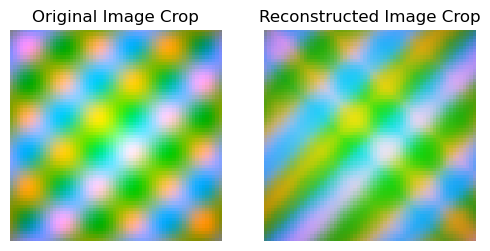


--- Lancement des tests comparatifs ---
Testing: Baseline (MSE, 256 units)...
Iter 1/1000, Loss: 0.075014, PSNR: 11.25 dB
Iter 500/1000, Loss: 0.019922, PSNR: 17.01 dB
Iter 1000/1000, Loss: 0.011140, PSNR: 19.53 dB
Testing: Loss L1 (256 units)...
Iter 1/1000, Loss: 0.226982, PSNR: 11.24 dB
Iter 500/1000, Loss: 0.129366, PSNR: 14.42 dB
Iter 1000/1000, Loss: 0.094718, PSNR: 16.42 dB
Testing: Loss Huber (256 units)...
Iter 1/1000, Loss: 0.037697, PSNR: 11.23 dB
Iter 500/1000, Loss: 0.010488, PSNR: 16.78 dB
Iter 1000/1000, Loss: 0.006263, PSNR: 19.02 dB
Testing: Small MLP (64 units)...
Iter 1/1000, Loss: 0.075873, PSNR: 11.20 dB
Iter 500/1000, Loss: 0.041368, PSNR: 13.83 dB
Iter 1000/1000, Loss: 0.025187, PSNR: 15.99 dB
Testing: Deep MLP (512 units, 6 layers)...
Iter 1/1000, Loss: 0.074790, PSNR: 11.26 dB
Iter 500/1000, Loss: 0.015218, PSNR: 18.18 dB
Iter 1000/1000, Loss: 0.007749, PSNR: 21.11 dB


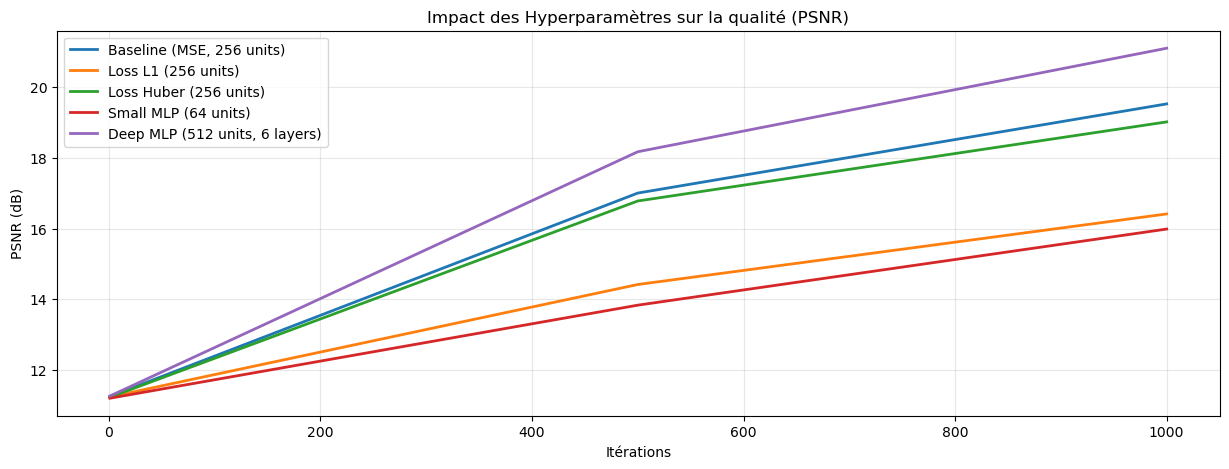

In [8]:
# Train and plot the training dynamics of the neural field model.
model = MLP(in_dim=2, hidden_dim=256, out_dim=3, num_layers=4).to(device)
num_iters = 2000
lr = 1e-3
trained_model, history = train_model(model, coords, colors, num_iters=num_iters, lr=lr, loss_type="mse", log_every=200)

# Show the final result of the neural field model.
trained_model.eval()
with torch.no_grad():
    pred_colors = trained_model(coords).cpu().numpy()
recon_img = pred_colors.reshape(resolution, resolution, 3)
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title("Original Image")
plt.imshow(img_np)
plt.axis('off')
plt.subplot(1, 2, 2)
plt.title("Reconstructed Image")
plt.imshow(recon_img)
plt.axis('off')
plt.show()

# Optional: how to show only partial results of the neural field model e.g., a crop.
crop_size = 64
start = (resolution - crop_size) // 2
end = start + crop_size
plt.figure(figsize=(6, 6))
plt.subplot(1, 2, 1)
plt.title("Original Image Crop")
plt.imshow(img_np[start:end, start:end, :])
plt.axis('off')
plt.subplot(1, 2, 2)
plt.title("Reconstructed Image Crop")
plt.imshow(recon_img[start:end, start:end, :])
plt.axis('off')
plt.show()

# Optional test different parameters of the neural field model: loss , model parameters, etc.

print("\n--- Lancement des tests comparatifs ---")

# 1. Définition des configurations à tester
experiments = [
    {"name": "Baseline (MSE, 256 units)", "loss": "mse", "hidden": 256, "num_layers": 4},
    {"name": "Loss L1 (256 units)",       "loss": "l1",  "hidden": 256, "num_layers": 4},
    {"name": "Loss Huber (256 units)",    "loss": "huber", "hidden": 256, "num_layers": 4},
    {"name": "Small MLP (64 units)",      "loss": "mse", "hidden": 64, "num_layers": 4},
    {"name": "Deep MLP (512 units, 6 layers)", "loss": "mse", "hidden": 512, "num_layers": 6},
]

results = {}

plt.figure(figsize=(15, 5))

# 2. Boucle d'entraînement pour chaque config
for i, exp in enumerate(experiments):
    print(f"Testing: {exp['name']}...")
    
    # Réinitialisation du modèle avec les nouveaux params
    model_test = MLP(in_dim=2, hidden_dim=exp['hidden'], out_dim=3, num_layers=4).to(device)
    
    # Entraînement (moins d'itérations pour que ça aille vite)
    _, hist = train_model(
        model_test, coords, colors, 
        num_iters=1000, lr=1e-3, 
        loss_type=exp['loss'], log_every=500
    )
    
    results[exp['name']] = hist
    
    # 3. Visualisation immédiate des courbes de PSNR
    plt.plot(hist['step'], hist['psnr'], label=exp['name'], linewidth=2)

# Mise en forme du graphique comparatif
plt.title("Impact des Hyperparamètres sur la qualité (PSNR)")
plt.xlabel("Itérations")
plt.ylabel("PSNR (dB)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


## Stage 2 – Positional Encoding

Positional encoding addresses the low-frequency bias by mapping coordinates into a higher-dimensional space that contains sinusoidal components. Two common variants are:

- Sinusoidal PE: deterministic frequencies with increasing scales. For each coordinate dimension and each frequency band (2^i), append sin(2^i\pi x) and cos(2^i\pi x).
- (Optional) Gaussian random Fourier features: sample a frequency matrix B from a Gaussian distribution and compute sin(2\pi Bx) and cos(2\pi Bx). The bandwidth (sigma) controls the frequency spread.

Read more from section 6.1 in [paper](https://arxiv.org/pdf/2006.10739).


In [19]:

class PositionalEncoding:
    # Utility class for positional encodings
    def __init__(self, pe_type: str = 'sin', num_freqs: int = 10, sigma: float = 10.0, input_dim: int = 2):
        ###########################################################
        ### TODO: complete the positional encoding
        ### Optional : implement the gaussian positional encoding
        ###########################################################
        self.pe_type = pe_type
        self.num_freqs = num_freqs
        self.sigma = sigma
        self.input_dim = input_dim


    def encode(self, coords: torch.Tensor) -> torch.Tensor:
        ###########################################################
        ### TODO: complete the positional encoding
        ### Optional : implement the gaussian positional encoding
        ###########################################################
        if self.pe_type == 'sin':
            encodings = [coords]
            for i in range(self.num_freqs):
                for func in [torch.sin, torch.cos]:
                    encodings.append(func((2.0 ** i) * np.pi * coords))
            return torch.cat(encodings, dim=-1)
        elif self.pe_type == 'gaussian':
            B = torch.randn((self.input_dim, self.num_freqs)) * self.sigma
            if B.device != coords.device:
                B = B.to(coords.device)
            projected = (2.0 * np.pi * coords) @ B
            return torch.cat([torch.sin(projected), torch.cos(projected)], dim=-1)
        else:
            raise ValueError(f"Unknown positional encoding type: {self.pe_type}")


def build_pe_mlp(pe: PositionalEncoding, hidden_dim: int = 128, num_layers: int = 4) -> nn.Module:
    ###########################################################
    ### TODO: complete the positional encoded mlp
    ###########################################################
    input_dim = pe.input_dim * (2 * pe.num_freqs + 1) if pe.pe_type == 'sin' else pe.num_freqs * 2
    model = MLP(in_dim=input_dim, hidden_dim=hidden_dim, out_dim=3, num_layers=num_layers).to(device)
    return model


Iter 1/2000, Loss: 0.077156, PSNR: 11.13 dB
Iter 200/2000, Loss: 0.000548, PSNR: 32.61 dB
Iter 400/2000, Loss: 0.000231, PSNR: 36.35 dB
Iter 600/2000, Loss: 0.000159, PSNR: 37.99 dB
Iter 800/2000, Loss: 0.000128, PSNR: 38.92 dB
Iter 1000/2000, Loss: 0.000107, PSNR: 39.71 dB
Iter 1200/2000, Loss: 0.000095, PSNR: 40.24 dB
Iter 1400/2000, Loss: 0.000087, PSNR: 40.63 dB
Iter 1600/2000, Loss: 0.000078, PSNR: 41.06 dB
Iter 1800/2000, Loss: 0.000076, PSNR: 41.17 dB
Iter 2000/2000, Loss: 0.000072, PSNR: 41.45 dB


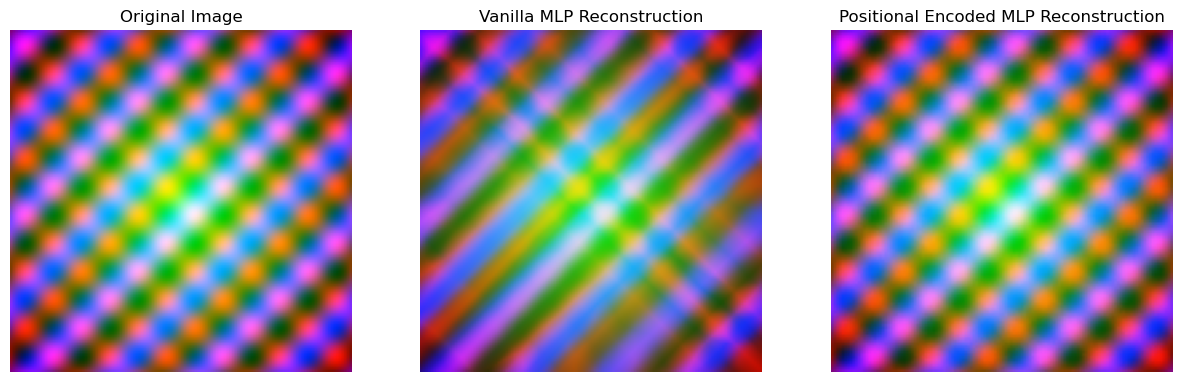


--- Comparing Sinusoidal vs Gaussian Positional Encodings ---
Iter 1/2000, Loss: 0.076658, PSNR: 11.15 dB
Iter 200/2000, Loss: 0.006138, PSNR: 22.12 dB
Iter 400/2000, Loss: 0.002876, PSNR: 25.41 dB
Iter 600/2000, Loss: 0.002154, PSNR: 26.67 dB
Iter 800/2000, Loss: 0.001849, PSNR: 27.33 dB
Iter 1000/2000, Loss: 0.001670, PSNR: 27.77 dB
Iter 1200/2000, Loss: 0.001393, PSNR: 28.56 dB
Iter 1400/2000, Loss: 0.001351, PSNR: 28.69 dB
Iter 1600/2000, Loss: 0.001237, PSNR: 29.08 dB
Iter 1800/2000, Loss: 0.001214, PSNR: 29.16 dB
Iter 2000/2000, Loss: 0.001278, PSNR: 28.93 dB


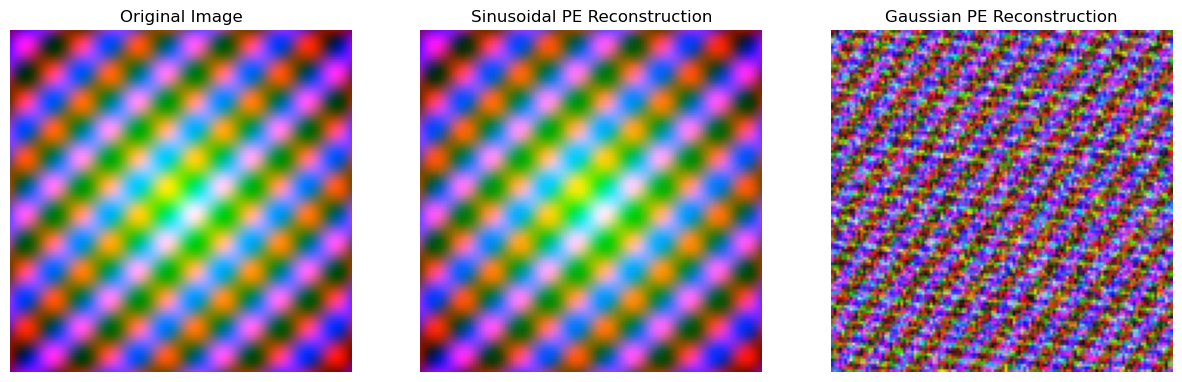

In [ ]:
num_freqs_sin = 32
num_features_gaussian = 64
hidden_dim = 128

# Train and plot the training dynamics of the Positional Encoded neural field model.
pe = PositionalEncoding(pe_type='sin', num_freqs=num_freqs_sin, input_dim=2)
pe_model = build_pe_mlp(pe, hidden_dim=hidden_dim, num_layers=4).to(device)
num_iters = 2000
lr = 1e-3
pe_trained_model, pe_history = train_model(pe_model,
                                         pe.encode(coords),
                                         colors,
                                            num_iters=num_iters,
                                            lr=lr,
                                            log_every=200)

# Show the final result of the neural field model and compare with the vanilla MLP version.
pe_trained_model.eval()
with torch.no_grad():
    pe_pred_colors = pe_trained_model(pe.encode(coords)).cpu().numpy()
pe_recon_img = pe_pred_colors.reshape(resolution, resolution, 3)
plt.figure(figsize=(15, 5))     
plt.subplot(1, 3, 1)
plt.title("Original Image")
plt.imshow(img_np)
plt.axis('off')
plt.subplot(1, 3, 2)
plt.title("Vanilla MLP Reconstruction")
plt.imshow(recon_img)
plt.axis('off')
plt.subplot(1, 3, 3)
plt.title("Positional Encoded MLP Reconstruction")
plt.imshow(pe_recon_img)
plt.axis('off')
plt.show()

# Optinal compare the different between sin and gaussian PEs.
print("\n--- Comparing Sinusoidal vs Gaussian Positional Encodings ---")
pe_gaussian = PositionalEncoding(pe_type='gaussian', num_freqs=num_features_gaussian, sigma=10.0, input_dim=2)
pe_gaussian_model = build_pe_mlp(pe_gaussian, hidden_dim=hidden_dim, num_layers=4).to(device)
gaussian_trained_model, gaussian_history = train_model(pe_gaussian_model,
                                                     pe_gaussian.encode(coords.to(device)),
                                                     colors,
                                                        num_iters=num_iters,
                                                        lr=lr,
                                                        log_every=200)
gaussian_trained_model.eval()
with torch.no_grad():
    gaussian_pred_colors = gaussian_trained_model(pe_gaussian.encode(coords)).cpu().numpy()
gaussian_recon_img = gaussian_pred_colors.reshape(resolution, resolution, 3)
plt.figure(figsize=(15, 5))     
plt.subplot(1, 3, 1)
plt.title("Original Image")
plt.imshow(img_np)
plt.axis('off')
plt.subplot(1, 3, 2)
plt.title("Sinusoidal PE Reconstruction")
plt.imshow(pe_recon_img)
plt.axis('off')
plt.subplot(1, 3, 3)
plt.title("Gaussian PE Reconstruction")
plt.imshow(gaussian_recon_img)
plt.axis('off')
plt.show()

# Optional test different parameters of the neural field model: num_freqs_sin, num_features_gaussian etc.


## Stage 3 – SIREN (Sinusoidal Representation Network)

Instead of injecting high-frequency information through the inputs (PE), SIREN modifies the network’s activations. Each hidden layer uses a sine nonlinearity $\sin(\omega_0 Wx + b)$ with a frequency scale $\omega_0$ and a specialized weight initialization. This enables representation of fine details and well-behaved derivatives.

See more in the [SIREN paper](https://arxiv.org/pdf/2006.09661).

Below we implement a basic SIREN and compare it to the PE-based models.


In [4]:

class SineLayer(nn.Module):
    # A single fully connected layer with sine activation and specialized initialization
    def __init__(self, in_features: int, out_features: int, bias: bool = True,
                 is_first: bool = False, omega_0: float = 30.0):
        super().__init__()
        ###########################################################
        ### TODO: complete the SineLayer class
        ###########################################################
        self.in_features = in_features
        self.is_first = is_first
        self.omega_0 = omega_0
        self.linear = nn.Linear(in_features, out_features, bias=bias)
        self.init_weights()
    

    def init_weights(self):
        with torch.no_grad():
            if self.is_first:
                # First layer initialization: weights ~ U(-1/in_features, 1/in_features)
                self.linear.weight.uniform_(-1 / self.in_features, 1 / self.in_features)
            else:
                # Subsequent layers: weights ~ U(-sqrt(6/in_features)/omega_0, sqrt(6/in_features)/omega_0)
                bound = np.sqrt(6 / self.in_features) / self.omega_0
                self.linear.weight.uniform_(-bound, bound)
            if self.linear.bias is not None:
                self.linear.bias.uniform_(-np.pi, np.pi)

    def forward(self, input: torch.Tensor) -> torch.Tensor:
        return torch.sin(self.omega_0 * self.linear(input))

class SIREN(nn.Module):
    ###########################################################
    ### TODO: define the SIREN class
    ### HINT: last layer should be linear to map to [0,1]
    ###########################################################
    def __init__(self, in_dim: int, hidden_dim: int, out_dim: int, num_layers: int = 5, omega_0: float = 30.0):
        super().__init__()
        layers = []
        layers.append(SineLayer(in_dim, hidden_dim, is_first=True, omega_0=omega_0))
        for _ in range(num_layers - 2):
            layers.append(SineLayer(hidden_dim, hidden_dim, is_first=False, omega_0=omega_0))
        layers.append(nn.Linear(hidden_dim, out_dim))  # Last layer is linear
        self.layers = nn.ModuleList(layers)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        for layer in self.layers[:-1]:
            x = layer(x)
        return torch.sigmoid(self.layers[-1](x))  # sigmoid bounds outputs in [0,1]

    

# Train a SIREN on raw coordinates (no positional encoding needed)
hidden_dim_siren = 256
num_layers_siren = 5
omega_0 = 30.0


Iter 1/2000, Loss: 0.092268, PSNR: 10.35 dB
Iter 200/2000, Loss: 0.000124, PSNR: 39.06 dB
Iter 400/2000, Loss: 0.000063, PSNR: 42.00 dB
Iter 600/2000, Loss: 0.000039, PSNR: 44.10 dB
Iter 800/2000, Loss: 0.000027, PSNR: 45.66 dB
Iter 1000/2000, Loss: 0.000021, PSNR: 46.83 dB
Iter 1200/2000, Loss: 0.000017, PSNR: 47.78 dB
Iter 1400/2000, Loss: 0.000014, PSNR: 48.65 dB
Iter 1600/2000, Loss: 0.000011, PSNR: 49.41 dB
Iter 1800/2000, Loss: 0.000010, PSNR: 50.17 dB
Iter 2000/2000, Loss: 0.000008, PSNR: 50.81 dB


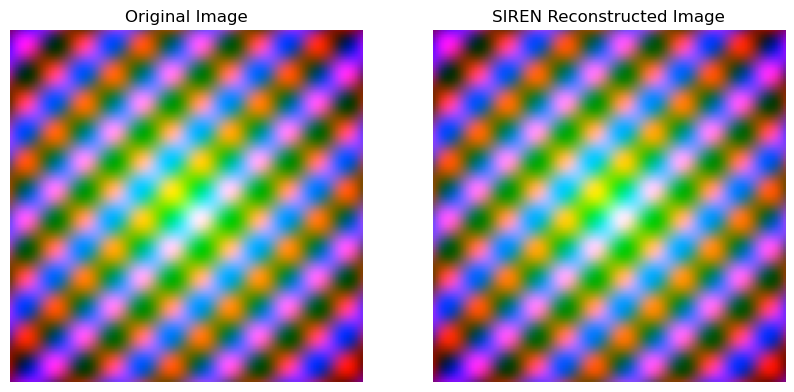


--- Testing SIREN with omega_0 = 1.0 ---
Iter 1/2000, Loss: 0.078888, PSNR: 11.03 dB
Iter 200/2000, Loss: 0.062413, PSNR: 12.05 dB
Iter 400/2000, Loss: 0.062364, PSNR: 12.05 dB
Iter 600/2000, Loss: 0.062327, PSNR: 12.05 dB
Iter 800/2000, Loss: 0.062286, PSNR: 12.06 dB
Iter 1000/2000, Loss: 0.062221, PSNR: 12.06 dB
Iter 1200/2000, Loss: 0.062121, PSNR: 12.07 dB
Iter 1400/2000, Loss: 0.061080, PSNR: 12.14 dB
Iter 1600/2000, Loss: 0.017792, PSNR: 17.50 dB
Iter 1800/2000, Loss: 0.012085, PSNR: 19.18 dB
Iter 2000/2000, Loss: 0.011063, PSNR: 19.56 dB


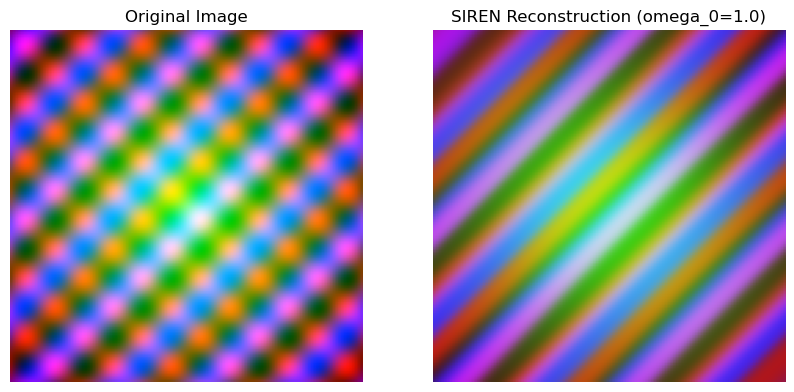


--- Testing SIREN with omega_0 = 10 ---
Iter 1/2000, Loss: 0.070678, PSNR: 11.51 dB
Iter 200/2000, Loss: 0.000776, PSNR: 31.10 dB
Iter 400/2000, Loss: 0.000364, PSNR: 34.39 dB
Iter 600/2000, Loss: 0.000216, PSNR: 36.66 dB
Iter 800/2000, Loss: 0.000152, PSNR: 38.19 dB
Iter 1000/2000, Loss: 0.000112, PSNR: 39.50 dB
Iter 1200/2000, Loss: 0.000087, PSNR: 40.62 dB
Iter 1400/2000, Loss: 0.000070, PSNR: 41.56 dB
Iter 1600/2000, Loss: 0.000057, PSNR: 42.42 dB
Iter 1800/2000, Loss: 0.000047, PSNR: 43.25 dB
Iter 2000/2000, Loss: 0.000039, PSNR: 44.05 dB


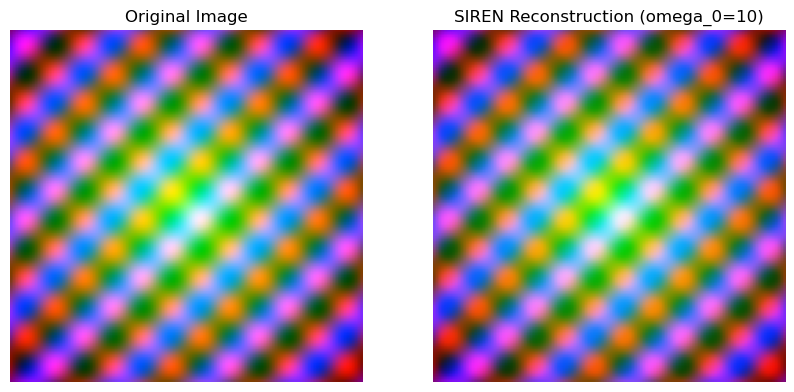


--- Testing SIREN with omega_0 = 20 ---
Iter 1/2000, Loss: 0.078985, PSNR: 11.02 dB
Iter 200/2000, Loss: 0.000248, PSNR: 36.05 dB
Iter 400/2000, Loss: 0.000115, PSNR: 39.39 dB
Iter 600/2000, Loss: 0.000075, PSNR: 41.24 dB
Iter 800/2000, Loss: 0.000053, PSNR: 42.75 dB
Iter 1000/2000, Loss: 0.000039, PSNR: 44.13 dB
Iter 1200/2000, Loss: 0.000029, PSNR: 45.33 dB
Iter 1400/2000, Loss: 0.000024, PSNR: 46.24 dB
Iter 1600/2000, Loss: 0.000019, PSNR: 47.10 dB
Iter 1800/2000, Loss: 0.000016, PSNR: 47.87 dB
Iter 2000/2000, Loss: 0.000014, PSNR: 48.48 dB


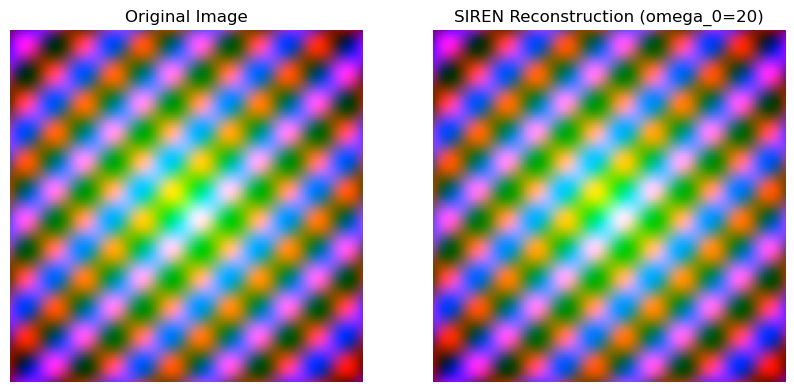

In [13]:
# Train and plot the training dynamics of the SIREN neural field model.
model = SIREN(in_dim=2, hidden_dim=hidden_dim_siren, out_dim=3, num_layers=num_layers_siren, omega_0=omega_0).to(device)
num_iters = 2000
lr = 1e-4
trained_model, history = train_model(model, coords, colors, num_iters=num_iters, lr=lr, loss_type="mse", log_every=200)


# Show the final result of the SIREN neural field model.
trained_model.eval()
with torch.no_grad():
    pred_colors = trained_model(coords).cpu().numpy()
recon_img = pred_colors.reshape(resolution, resolution, 3)
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)            
plt.title("Original Image")
plt.imshow(img_np)
plt.axis('off')
plt.subplot(1, 2, 2)    
plt.title("SIREN Reconstructed Image")
plt.imshow(recon_img)
plt.axis('off')
plt.show()



# Optional test different parameters of the neural field model: omega_0;
omega_0_values = [1.0, 10, 20]
results = {}
for omega in omega_0_values:
    print(f"\n--- Testing SIREN with omega_0 = {omega} ---")
    siren_model = SIREN(in_dim=2, hidden_dim=hidden_dim_siren, out_dim=3, num_layers=num_layers_siren, omega_0=omega).to(device)
    siren_trained_model, siren_history = train_model(siren_model,
                                                   coords,
                                                   colors,
                                                       num_iters=num_iters,
                                                       lr=lr,
                                                       log_every=200)
    results[f"omega_0={omega}"] = siren_history

    # Visualize the reconstruction
    siren_trained_model.eval()
    with torch.no_grad():
        siren_pred_colors = siren_trained_model(coords).cpu().numpy()
    siren_recon_img = siren_pred_colors.reshape(resolution, resolution, 3)
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)            
    plt.title("Original Image")
    plt.imshow(img_np)
    plt.axis('off')
    plt.subplot(1, 2, 2)    
    plt.title(f"SIREN Reconstruction (omega_0={omega})")
    plt.imshow(siren_recon_img)
    plt.axis('off')
    plt.show()


# Try a bit the super resolution (e.g. 4x) with the SIREN neural field model and compare to the original image.

Iter 1/2000, Loss: 0.099134, PSNR: 10.04 dB
Iter 200/2000, Loss: 0.000107, PSNR: 39.72 dB
Iter 400/2000, Loss: 0.000049, PSNR: 43.10 dB
Iter 600/2000, Loss: 0.000029, PSNR: 45.32 dB
Iter 800/2000, Loss: 0.000020, PSNR: 47.09 dB
Iter 1000/2000, Loss: 0.000014, PSNR: 48.55 dB
Iter 1200/2000, Loss: 0.000065, PSNR: 41.84 dB
Iter 1400/2000, Loss: 0.000008, PSNR: 50.88 dB
Iter 1600/2000, Loss: 0.000007, PSNR: 51.73 dB
Iter 1800/2000, Loss: 0.000005, PSNR: 52.71 dB
Iter 2000/2000, Loss: 0.000004, PSNR: 53.55 dB


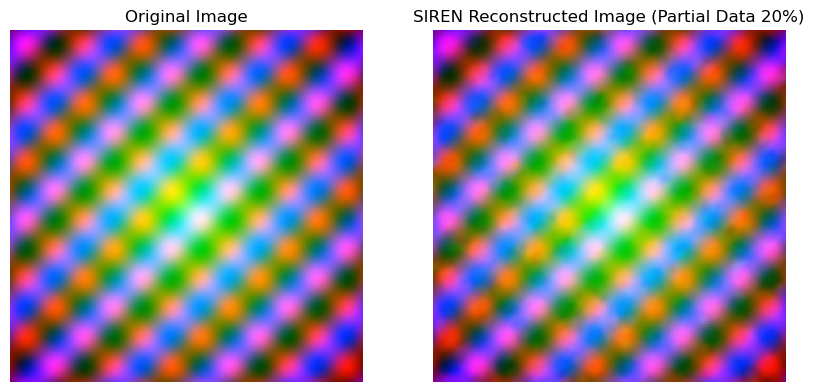

In [24]:
# [Bonus]

# try to use only partial data to train the SIREN or PE model
# sample only 10% to 30% of data and train the model

partial_ratio = 0.2  # use 20% of the data
num_samples = int(coords.shape[0] * partial_ratio)
perm = torch.randperm(coords.shape[0])
sampled_indices = perm[:num_samples]
sampled_coords = coords[sampled_indices]
sampled_colors = colors[sampled_indices]    
# Train SIREN on partial data
siren_model_partial = SIREN(in_dim=2, hidden_dim=hidden_dim_siren, out_dim=3, num_layers=num_layers_siren, omega_0=omega_0).to(device)
siren_trained_model_partial, siren_history_partial = train_model(siren_model_partial,
                                                               sampled_coords,
                                                               sampled_colors,
                                                               num_iters=num_iters,
                                                               lr=lr,
                                                                log_every=200)
# Show the final result of the SIREN neural field model trained on partial data.
siren_trained_model_partial.eval()
with torch.no_grad():
    pred_colors_partial = siren_trained_model_partial(coords).cpu().numpy()
recon_img_partial = pred_colors_partial.reshape(resolution, resolution, 3)
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)            
plt.title("Original Image")
plt.imshow(img_np)  
plt.axis('off')
plt.subplot(1, 2, 2)    
plt.title(f"SIREN Reconstructed Image (Partial Data {partial_ratio*100:.0f}%)")
plt.imshow(recon_img_partial)
plt.axis('off')
plt.show()